# Phase 3: Text Classification (Neural)

**Dataset:** `szzs1693/intro-nlp-thai-news` — 3 categories: `politics`, `economics`, `social`

In [1]:
# Setup Thai font for matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

!wget -q -O thsarabunnew-webfont.ttf https://github.com/PyThaiNLP/prachathai-67k/raw/master/thsarabunnew-webfont.ttf

fm.fontManager.addfont("thsarabunnew-webfont.ttf")
plt.rc('font', family='TH Sarabun New')

## 1. Load Dataset

In [2]:
from datasets import load_dataset
ds = load_dataset("szzs1693/intro-nlp-thai-news")
df = ds["train"].to_pandas()
df.head()

,url,date,title,body_text,category,source
0,https://prachatai.com/print/2575,2005-02-03 02:09:00,ปากคำแก๊งหน้าดารา : อันธพาลกวนเมือง หรือ?,คดีซามูไรผมแดงครั้งนั้น กลายเป็นข่าวใหญ่โตทั้ง...,social,prachathai
1,https://prachatai.com/print/4921,2005-07-16 10:17:00,วิษณุแจงออก พ.ร.ก.. ฉุกเฉินเพื่อบูรณาการกฎหมาย,[1]\nประชาไท15 ก.ค. 2548 นายวิษณุ เครืองาม รอ...,politics,prachathai
2,https://prachatai.com/print/4923,2005-07-16 10:18:00,คำอธิบายพระราชกำหนดบริหารราชการในสถานการณ์ฉุกเ...,ภายหลังการประชุมคณะรัฐนตรีนัดพิเศษ นายวิษณุ เค...,politics,prachathai
3,https://prachatai.com/print/4939,2005-07-18 01:49:00,อนุกรรมการสมานฉันท์ฯถกพรก.ฉุกเฉิน,นายอับดุลอาซิซ ตาเดอินทร์ รองนายกสมาคมยุวมุสลิ...,politics,prachathai
4,https://prachatai.com/print/4945,2005-07-18 16:26:00,"โพลระบุ ""คน 3 จว.ใต้-กทม."" หนุนรัฐออกกม.สถานกา...",สำนักวิจัยเอแบคโพลล์ มหาวิทยาลัยอัสสัมชัญ ได้ส...,politics,prachathai


In [3]:
print(f"Shape: {df.shape}")
print(f"\nNull values:\n{df.isnull().sum()}")
print(f"\nDtypes:\n{df.dtypes}")

Shape: (6603, 6)

Null values:
url          0
date         0
title        0
body_text    0
category     0
source       0
dtype: int64

Dtypes:
url                     str
date         datetime64[us]
title                   str
body_text               str
category                str
source                  str
dtype: object


## 2. Preprocessing

ภาษาไทยไม่มีช่องว่างระหว่างคำ ต้องแบ่งคำ (word segmentation) ด้วยตัวเองก่อนส่งเข้า library อื่น ๆ ไปใช้งาน

ใช้ `pythainlp` `newmm` engine (dictionary-based maximum matching), แล้วเชื่อมด้วยช่องวาง (space) เพื่อให้ `TfidfVectorizer` เข้าใจและแบ่งคำได้

In [4]:
%pip install pythainlp

Note: you may need to restart the kernel to use updated packages.


In [5]:
from pythainlp.tokenize import word_tokenize

def tokenize(text: str) -> str:
    tokens = word_tokenize(text, engine="newmm", keep_whitespace=False)
    return " ".join(tokens)

In [6]:
from tqdm import tqdm
# This cell is slow (~5–10 min depending on hardware). Run once and proceed.
tqdm.pandas(desc="Tokenizing")
df["tokenized_text"] = df["body_text"].progress_apply(tokenize)

Tokenizing: 100%|██████████████████████████████████████████████████████████████| 6603/6603 [00:36<00:00, 182.66it/s]


In [7]:
# Sanity check — compare raw vs tokenized for one article
sample = df.iloc[0]
print("=== RAW (first 300 chars) ===")
print(sample["body_text"][:300])
print("\n=== TOKENIZED (first 300 chars) ===")
print(sample["tokenized_text"][:300])

=== RAW (first 300 chars) ===
คดีซามูไรผมแดงครั้งนั้น กลายเป็นข่าวใหญ่โตทั้งหนังสือพิมพ์ วิทยุและทีวี ทำให้คนรู้จักกลุ่มของพวกเราไปทั้งประเทศ ผมไม่อยากพูดถึง เพราะมันเป็นความผิดที่ทำให้เราถูกเกลียดชัง ถูกจับจ้องมองทั้งจากตำรวจและจากแหล่งสื่อต่างๆ
คดีที่เกิดขึ้นหลายครั้งต่อมา ทั้งสื่อ ตำรวจ และสังคมต่างพากันประโคมข่าวว่า เป็นกลุ่

=== TOKENIZED (first 300 chars) ===
คดี ซามูไร ผม แดง ครั้งนั้น กลาย เป็นข่าว ใหญ่โต ทั้ง หนังสือพิมพ์ วิทยุ และ ทีวี ทำให้ คนรู้จัก กลุ่ม ของ พวกเรา ไป ทั้ง ประเทศ ผม ไม่ อยาก พูดถึง เพราะ มัน เป็นความ ผิดที่ ทำให้ เรา ถูก เกลียดชัง ถูกจับ จ้องมอง ทั้ง จาก ตำรวจ และ จาก แหล่ง สื่อ ต่างๆ 
 คดี ที่ เกิดขึ้น หลาย ครั้งต่อมา ทั้ง สื่อ ตำ


## 3. Train / Validation / Test Split

We use a **70 / 15 / 15** stratified split to preserve class balance across all three sets.

**3.1 Stratified Train/Test Split (Category + Source)**

In [8]:
# สร้าง composite key เพื่อ stratify ทั้ง category และ source
df["stratify_key"] = df["category"] + "_" + df["source"]

from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["stratify_key"],
    random_state=42
)

print("Train size:", len(train_df))
print("Test size:", len(test_df))

Train size: 5282
Test size: 1321


In [9]:
train_df, val_df = train_test_split(
    train_df,
    test_size=0.176,  # ทำให้ final val ≈ 15%
    stratify=train_df["stratify_key"],
    random_state=42
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 4352
Validation: 930
Test: 1321


**3.2 Prepare X, y**

In [10]:
X_train = train_df["tokenized_text"]
X_test = test_df["tokenized_text"]

X_val = val_df["tokenized_text"]
y_val = val_df["category"]

y_train = train_df["category"]
y_test = test_df["category"]

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc = le.transform(y_val)
y_test_enc = le.transform(y_test)

**Part 2: Model**

**STEP 1: Train Word2Vec**

In [11]:
%pip install gensim

Note: you may need to restart the kernel to use updated packages.


In [12]:
sentences = df["tokenized_text"].apply(lambda x: x.split())

from gensim.models import Word2Vec

w2v_model = Word2Vec(
    sentences,
    vector_size=100,   # ขนาด embedding
    window=5,
    min_count=2,
    workers=4,
    sg=1               # 1 = skip-gram
)

**STEP 2 : สร้าง Tokenizer**

In [13]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer()
tokenizer.fit_on_texts(train_df["tokenized_text"])

X_train_seq = tokenizer.texts_to_sequences(train_df["tokenized_text"])
X_val_seq   = tokenizer.texts_to_sequences(val_df["tokenized_text"])
X_test_seq  = tokenizer.texts_to_sequences(test_df["tokenized_text"])

max_len = 200

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_val_pad   = pad_sequences(X_val_seq, maxlen=max_len)
X_test_pad  = pad_sequences(X_test_seq, maxlen=max_len)

2026-03-05 22:49:19.289002: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-05 22:49:19.289284: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-05 22:49:19.313474: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-05 22:49:20.576401: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation or

**STEP 3: สร้าง Embedding Matrix จาก Word2Vec**

In [14]:
import numpy as np

embedding_dim = 100
word_index = tokenizer.word_index
vocab_size = len(word_index) + 1

embedding_matrix = np.zeros((vocab_size, embedding_dim))

for word, i in word_index.items():
    if word in w2v_model.wv:
        embedding_matrix[i] = w2v_model.wv[word]

**STEP 4: สร้าง RNN**

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout

rnn_model = Sequential([
    Embedding(input_dim=vocab_size,
              output_dim=embedding_dim,
              weights=[embedding_matrix],
              trainable=False),
    SimpleRNN(64),
    Dropout(0.5),
    Dense(len(le.classes_), activation="softmax")
])

rnn_model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

rnn_model.summary()

2026-03-05 22:49:26.041267: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     4,668,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,668,600 (17.81 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 4,668,600 (17.81 MB)

**STEP 5: สร้าง LSTM Model**

In [16]:
from tensorflow.keras.layers import LSTM

lstm_model = Sequential([
    Embedding(input_dim=vocab_size,
              output_dim=embedding_dim,
              weights=[embedding_matrix],
              input_length=max_len,
              trainable=False),
    LSTM(64),
    Dropout(0.5),
    Dense(len(le.classes_), activation="softmax")
])

lstm_model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

lstm_model.summary()

/home/lemasc/projects/nlp-news-thai/.venv/lib/python3.13/site-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │     4,668,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,668,600 (17.81 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 4,668,600 (17.81 MB)

**STEP 6: Train (ใช้ Validation)**

In [17]:
history_rnn = rnn_model.fit(
    X_train_pad, y_train_enc,
    validation_data=(X_val_pad, y_val_enc),
    epochs=5,
    batch_size=32
)

history_lstm = lstm_model.fit(
    X_train_pad, y_train_enc,
    validation_data=(X_val_pad, y_val_enc),
    epochs=5,
    batch_size=32
)

Epoch 1/5
136/136 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.4044 - loss: 1.1778 - val_accuracy: 0.4946 - val_loss: 1.0279
Epoch 2/5
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5340 - loss: 0.9938 - val_accuracy: 0.5892 - val_loss: 0.9043
Epoch 3/5
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5319 - loss: 1.0059 - val_accuracy: 0.4161 - val_loss: 1.0713
Epoch 4/5
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.4552 - loss: 1.0501 - val_accuracy: 0.4849 - val_loss: 1.0284
Epoch 5/5
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5248 - loss: 0.9781 - val_accuracy: 0.6237 - val_loss: 0.8423
Epoch 1/5
136/136 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.5443 - loss: 0.9413 - val_accuracy: 0.6774 - val_loss: 0.7870
Epoch 2/5
136/136 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.6482 - loss: 0.8359 - val_accuracy: 0.6645 - val_loss: 0.8179
Epoch 3/5
136/136 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.6873 - loss: 0.7877 - val_accuracy: 0.6828

**STEP 7: Evaluate + F1 Macro**

In [18]:
import numpy as np
from sklearn.metrics import classification_report, f1_score

# Predict
y_pred_rnn = np.argmax(rnn_model.predict(X_test_pad), axis=1)
y_pred_lstm = np.argmax(lstm_model.predict(X_test_pad), axis=1)

print("=== RNN ===")
print(classification_report(y_test_enc, y_pred_rnn, target_names=le.classes_))

print("=== LSTM ===")
print(classification_report(y_test_enc, y_pred_lstm, target_names=le.classes_))

# F1 Macro
f1_rnn = f1_score(y_test_enc, y_pred_rnn, average="macro")
f1_lstm = f1_score(y_test_enc, y_pred_lstm, average="macro")

print("F1 Macro RNN:", f1_rnn)
print("F1 Macro LSTM:", f1_lstm)

42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
=== RNN ===
              precision    recall  f1-score   support

   economics       0.71      0.68      0.70       441
    politics       0.61      0.68      0.64       440
      social       0.59      0.55      0.57       440

    accuracy                           0.64      1321
   macro avg       0.64      0.64      0.63      1321
weighted avg       0.64      0.64      0.63      1321

=== LSTM ===
              precision    recall  f1-score   support

   economics       0.66      0.78      0.72       441
    politics       0.67      0.75      0.71       440
      social       0.66      0.46      0.54       440

    accuracy                           0.66      1321
   macro avg       0.66      0.66      0.66      1321
weighted avg       0.66      0.66      0.66      1321

F1 Macro RNN: 0.6345858759446544
F1 Macro LSTM: 0.6551840020270894


**STEP 8: Confusion Matrix (Normalized)**

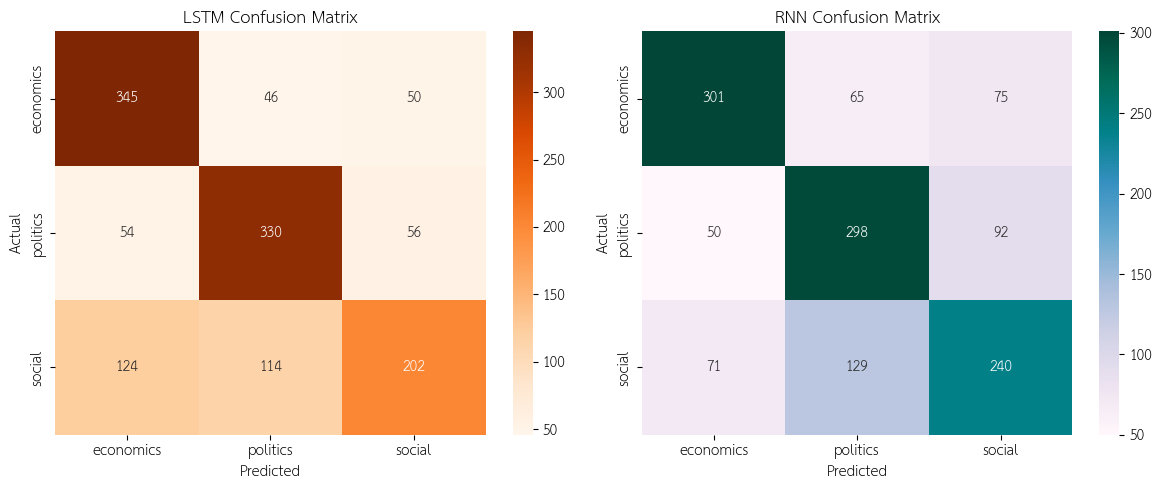

In [19]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

labels_for_plot = le.classes_

cm_lstm = confusion_matrix(y_test_enc, y_pred_lstm, labels=range(len(labels_for_plot)))
cm_rnn = confusion_matrix(y_test_enc, y_pred_rnn, labels=range(len(labels_for_plot)))

fig, axes = plt.subplots(1, 2, figsize=(12,5))

# LSTM
sns.heatmap(cm_lstm,
            annot=True,
            fmt="d",
            cmap="Oranges",
            xticklabels=labels_for_plot,
            yticklabels=labels_for_plot,
            ax=axes[0])
axes[0].set_title("LSTM Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# RNN
sns.heatmap(cm_rnn,
            annot=True,
            fmt="d",
            cmap="PuBuGn",
            xticklabels=labels_for_plot,
            yticklabels=labels_for_plot,
            ax=axes[1])
axes[1].set_title("RNN Confusion Matrix") # Corrected title
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()